### Imports Block

In [1]:
import pandas as pd
import glob
import re
import os
import sys
import pickle
import datetime
import numpy as np
import matplotlib.pyplot as plt

from datetime import datetime
from sklearn import tree, metrics
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from scipy.signal import butter, filtfilt, find_peaks
from sklearn.tree import DecisionTreeClassifier,export_graphviz

# -- IMPORTS END --

# enable zooming into graphs
%matplotlib inline
plt.rcParams['figure.figsize'] = [9, 6] # width, height in inches

### Helper function: calc_magnitude

In [2]:
def calc_magnitude(data):

    # Calculate magnitude
    data['accel_mag'] = np.sqrt(data['x']**2 + data['y']**2 + data['z']**2)
    data['accel_mag'] = data['accel_mag'] - data['accel_mag'].mean()

    return data

### Helper function: remove_noise

In [3]:
def remove_noise(data,sampling_rate):
    from scipy.signal import butter, filtfilt, find_peaks

    # Low pass filter
    cutoff = 5 # Hz
    order = 2
    b, a = butter(order, cutoff/(sampling_rate/2), btype='lowpass')
    data['filtered_accel_mag'] = filtfilt(b, a, data['accel_mag'])

    return data


### Helper function: add_features
Step 3: technical implementation, time-domain, key features (mean, median, etc)

In [4]:
def add_features(window):
    features = {
        'avg': window['filtered_accel_mag'].mean(),
        'max': window['filtered_accel_mag'].quantile(1),
        'med': window['filtered_accel_mag'].quantile(0.5),
        'min': window['filtered_accel_mag'].quantile(0),
        'q25': window['filtered_accel_mag'].quantile(0.25),
        'q75': window['filtered_accel_mag'].quantile(0.75),
        'std': window['filtered_accel_mag'].std(),
        'range': window['filtered_accel_mag'].quantile(1) - window['filtered_accel_mag'].quantile(0),
        'skewness': window['filtered_accel_mag'].skew()
    }

    print("Extracted features from one window:")
    print(pd.DataFrame([features]))

    return pd.DataFrame([features])


### Load and Combine Data

In [5]:
base_path = 'data/'
postures = ['goodposture', 'mildposture', 'badposture']
sampling_rate = 100  # Hz
window_size = int(2 * sampling_rate)  # 2 seconds

frames = pd.DataFrame()

for posture in postures:
    folder_path = os.path.join(base_path, posture)
    acc_files = glob.glob(os.path.join(folder_path, 'Accelerometer*.csv'))

    for acc_file in acc_files:
        print(f"\n📁 Processing file: {acc_file}")
        df = pd.read_csv(acc_file)
        df.columns = df.columns.str.lower()

        if not set(['x', 'y', 'z']).issubset(df.columns):
            print("Skipped: Missing x, y, z columns")
            continue

        df = df[['x', 'y', 'z']]
        df = calc_magnitude(df)
        df = remove_noise(df, sampling_rate)

        num_windows = len(df) // window_size

        for i in range(num_windows):
            start = i * window_size
            end = start + window_size
            window = df.iloc[start:end]

            if len(window) == window_size:
                features = add_features(window)
                features['activity'] = posture
                frames = pd.concat([frames, features], ignore_index=True)

                if i < 1:
                    print(f"Window {i} features:\n", features)

# --- Summary ---
print(f"TOTAL rows extracted: {len(frames)}")
print("Samples per posture class:")
print(frames['activity'].value_counts())



📁 Processing file: data/goodposture/AccelerometerMM.csv
Extracted features from one window:
        avg       max       med       min      q25      q75       std  \
0  0.063916  0.121588  0.062138  0.000497  0.05181  0.07419  0.018542   

      range  skewness  
0  0.121091  0.511479  
Window 0 features:
         avg       max       med       min      q25      q75       std  \
0  0.063916  0.121588  0.062138  0.000497  0.05181  0.07419  0.018542   

      range  skewness     activity  
0  0.121091  0.511479  goodposture  
Extracted features from one window:
        avg       max      med       min       q25       q75       std  \
0  0.061408  0.103273  0.06167  0.030796  0.049361  0.071341  0.015534   

      range  skewness  
0  0.072477  0.163049  
Extracted features from one window:
        avg       max       med       min       q25       q75      std  \
0  0.060463  0.116922  0.059029  0.031229  0.048923  0.070212  0.01587   

      range  skewness  
0  0.085692  0.836775  
Extra

### Helper function: train_decision_tree
(This is the model we use for classification and this tells us the training methodology. Training 70%, testing 30%)

In [6]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

def train_decision_tree(frames):
    feature_cols = ['avg', 'max', 'med', 'min', 'q25', 'q75', 'std', 'range', 'skewness']
    X = frames[feature_cols]
    y = frames['activity']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y)

    model = DecisionTreeClassifier(criterion='entropy', max_depth=5)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

    print("Classification Report:\n", classification_report(y_test, y_pred))
    print("Accuracy:", acc)

    return model, cm, acc, model.classes_, X_test, y_test

model, cm, acc, class_names, X_test, y_test = train_decision_tree(frames)

Classification Report:
               precision    recall  f1-score   support

  badposture       0.48      0.50      0.49       145
 goodposture       0.45      0.71      0.55       145
 mildposture       0.64      0.22      0.33       135

    accuracy                           0.48       425
   macro avg       0.52      0.48      0.46       425
weighted avg       0.52      0.48      0.46       425

Accuracy: 0.4823529411764706


### Visualization of Decision Tree

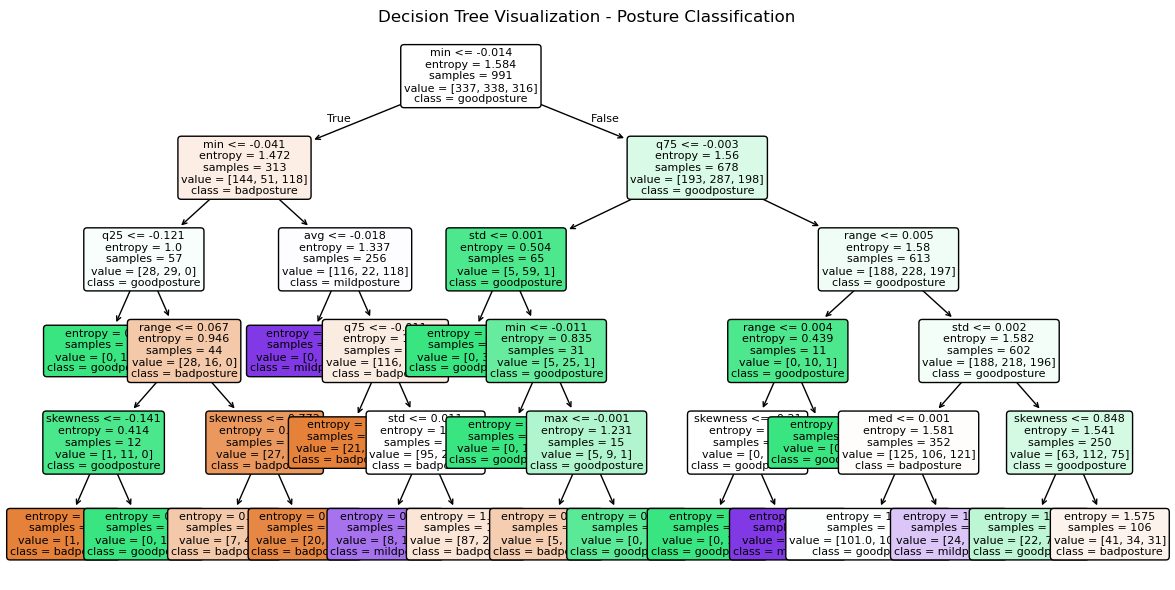

In [7]:
from sklearn.tree import plot_tree

plt.figure(figsize=(12, 6))
plot_tree(
    model,
    feature_names=['avg', 'max', 'med', 'min', 'q25', 'q75', 'std', 'range', 'skewness'],
    class_names=class_names,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Decision Tree Visualization - Posture Classification")
plt.tight_layout()
plt.show()


### Window Approach: Sliding Approach

In [8]:
import pandas as pd
import numpy as np
import os
import glob
from scipy.signal import butter, filtfilt

base_path = 'data/'
postures = ['goodposture', 'mildposture', 'badposture']
sampling_rate = 100 
window_size = int(2 * sampling_rate)  

frames = pd.DataFrame() 

for posture in postures:
    folder_path = os.path.join(base_path, posture)
    acc_files = glob.glob(os.path.join(folder_path, 'Accelerometer*.csv'))

    for acc_file in acc_files:
        df = pd.read_csv(acc_file)
        df.columns = df.columns.str.lower()

        if not set(['x', 'y', 'z']).issubset(df.columns):
            continue

        df = df[['x', 'y', 'z']] 
        df = calc_magnitude(df)
        df = remove_noise(df, sampling_rate)

        num_windows = len(df) // window_size

        for i in range(num_windows):
            start = i * window_size
            end = start + window_size
            window = df.iloc[start:end]

            if len(window) == window_size:
                features = add_features(window)
                features['activity'] = posture
                frames = pd.concat([frames, features], ignore_index=True)

# Final check
print(f"Total samples extracted: {len(frames)}")
print("Samples per class:")
print(frames['activity'].value_counts())

Extracted features from one window:
        avg       max       med       min      q25      q75       std  \
0  0.063916  0.121588  0.062138  0.000497  0.05181  0.07419  0.018542   

      range  skewness  
0  0.121091  0.511479  
Extracted features from one window:
        avg       max      med       min       q25       q75       std  \
0  0.061408  0.103273  0.06167  0.030796  0.049361  0.071341  0.015534   

      range  skewness  
0  0.072477  0.163049  
Extracted features from one window:
        avg       max       med       min       q25       q75      std  \
0  0.060463  0.116922  0.059029  0.031229  0.048923  0.070212  0.01587   

      range  skewness  
0  0.085692  0.836775  
Extracted features from one window:
        avg       max       med       min       q25       q75       std  \
0  0.052084  0.077909  0.052032  0.027415  0.045612  0.058962  0.010673   

      range  skewness  
0  0.050494  0.026491  
Extracted features from one window:
        avg       max       med 

### Confusion Matrix

<Figure size 600x500 with 0 Axes>

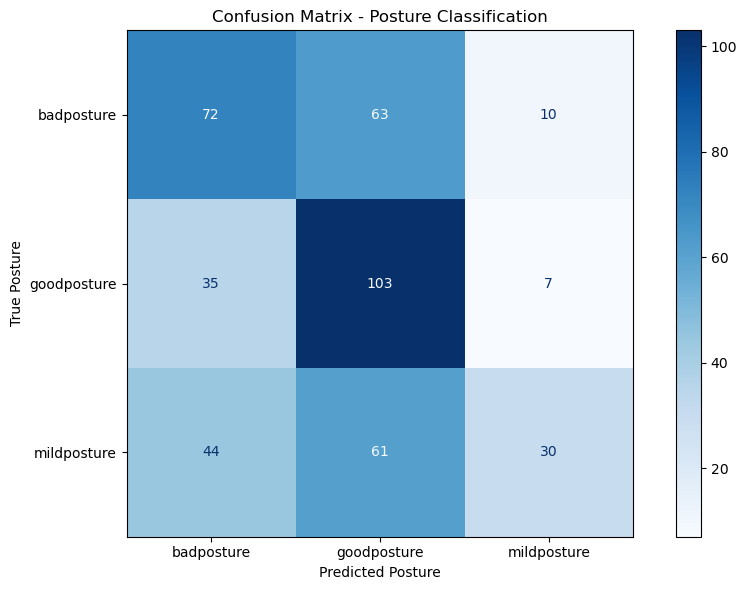

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_confusion_matrix(model, X_test, y_test):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)

    plt.figure(figsize=(6, 5))
    disp.plot(cmap='Blues', values_format='d')
    plt.title("Confusion Matrix - Posture Classification")
    plt.xlabel("Predicted Posture")
    plt.ylabel("True Posture")
    plt.grid(False)
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(model, X_test, y_test)



### Scatter Plot

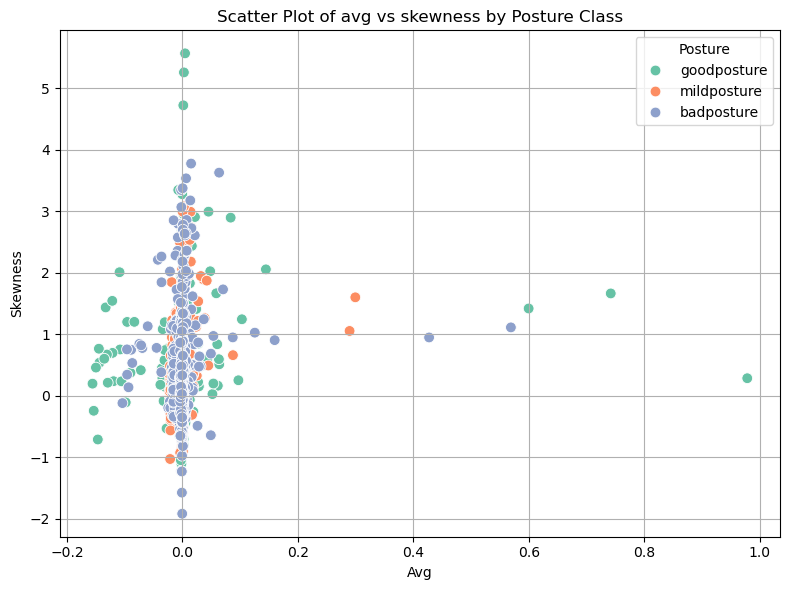

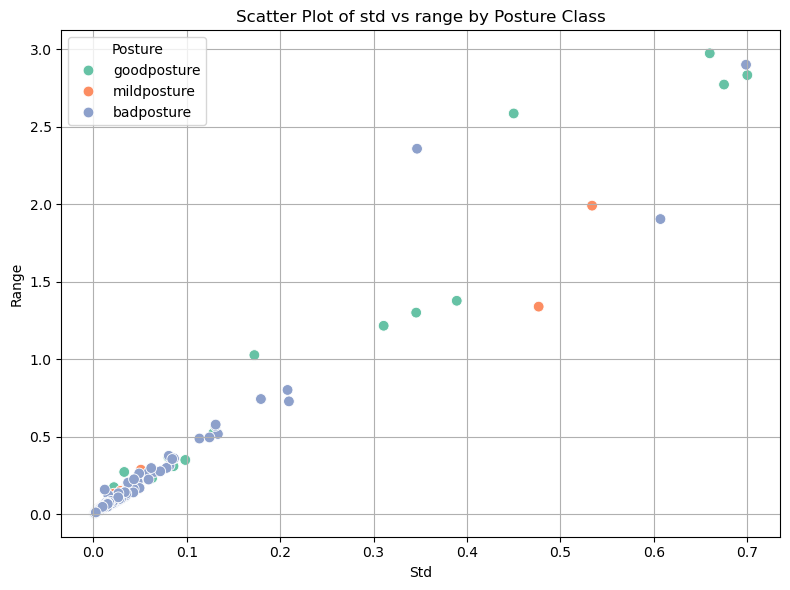

In [10]:
import seaborn as sns

def plot_feature_scatter(frames, feature_x='avg', feature_y='skewness'):
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=frames, x=feature_x, y=feature_y, hue='activity', palette='Set2', s=60)
    plt.title(f"Scatter Plot of {feature_x} vs {feature_y} by Posture Class")
    plt.xlabel(feature_x.capitalize())
    plt.ylabel(feature_y.capitalize())
    plt.legend(title='Posture')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_feature_scatter(frames, 'avg', 'skewness')
plot_feature_scatter(frames, 'std', 'range')  


### Plot All Feature Pairs Automatically (Scatter Matrix)

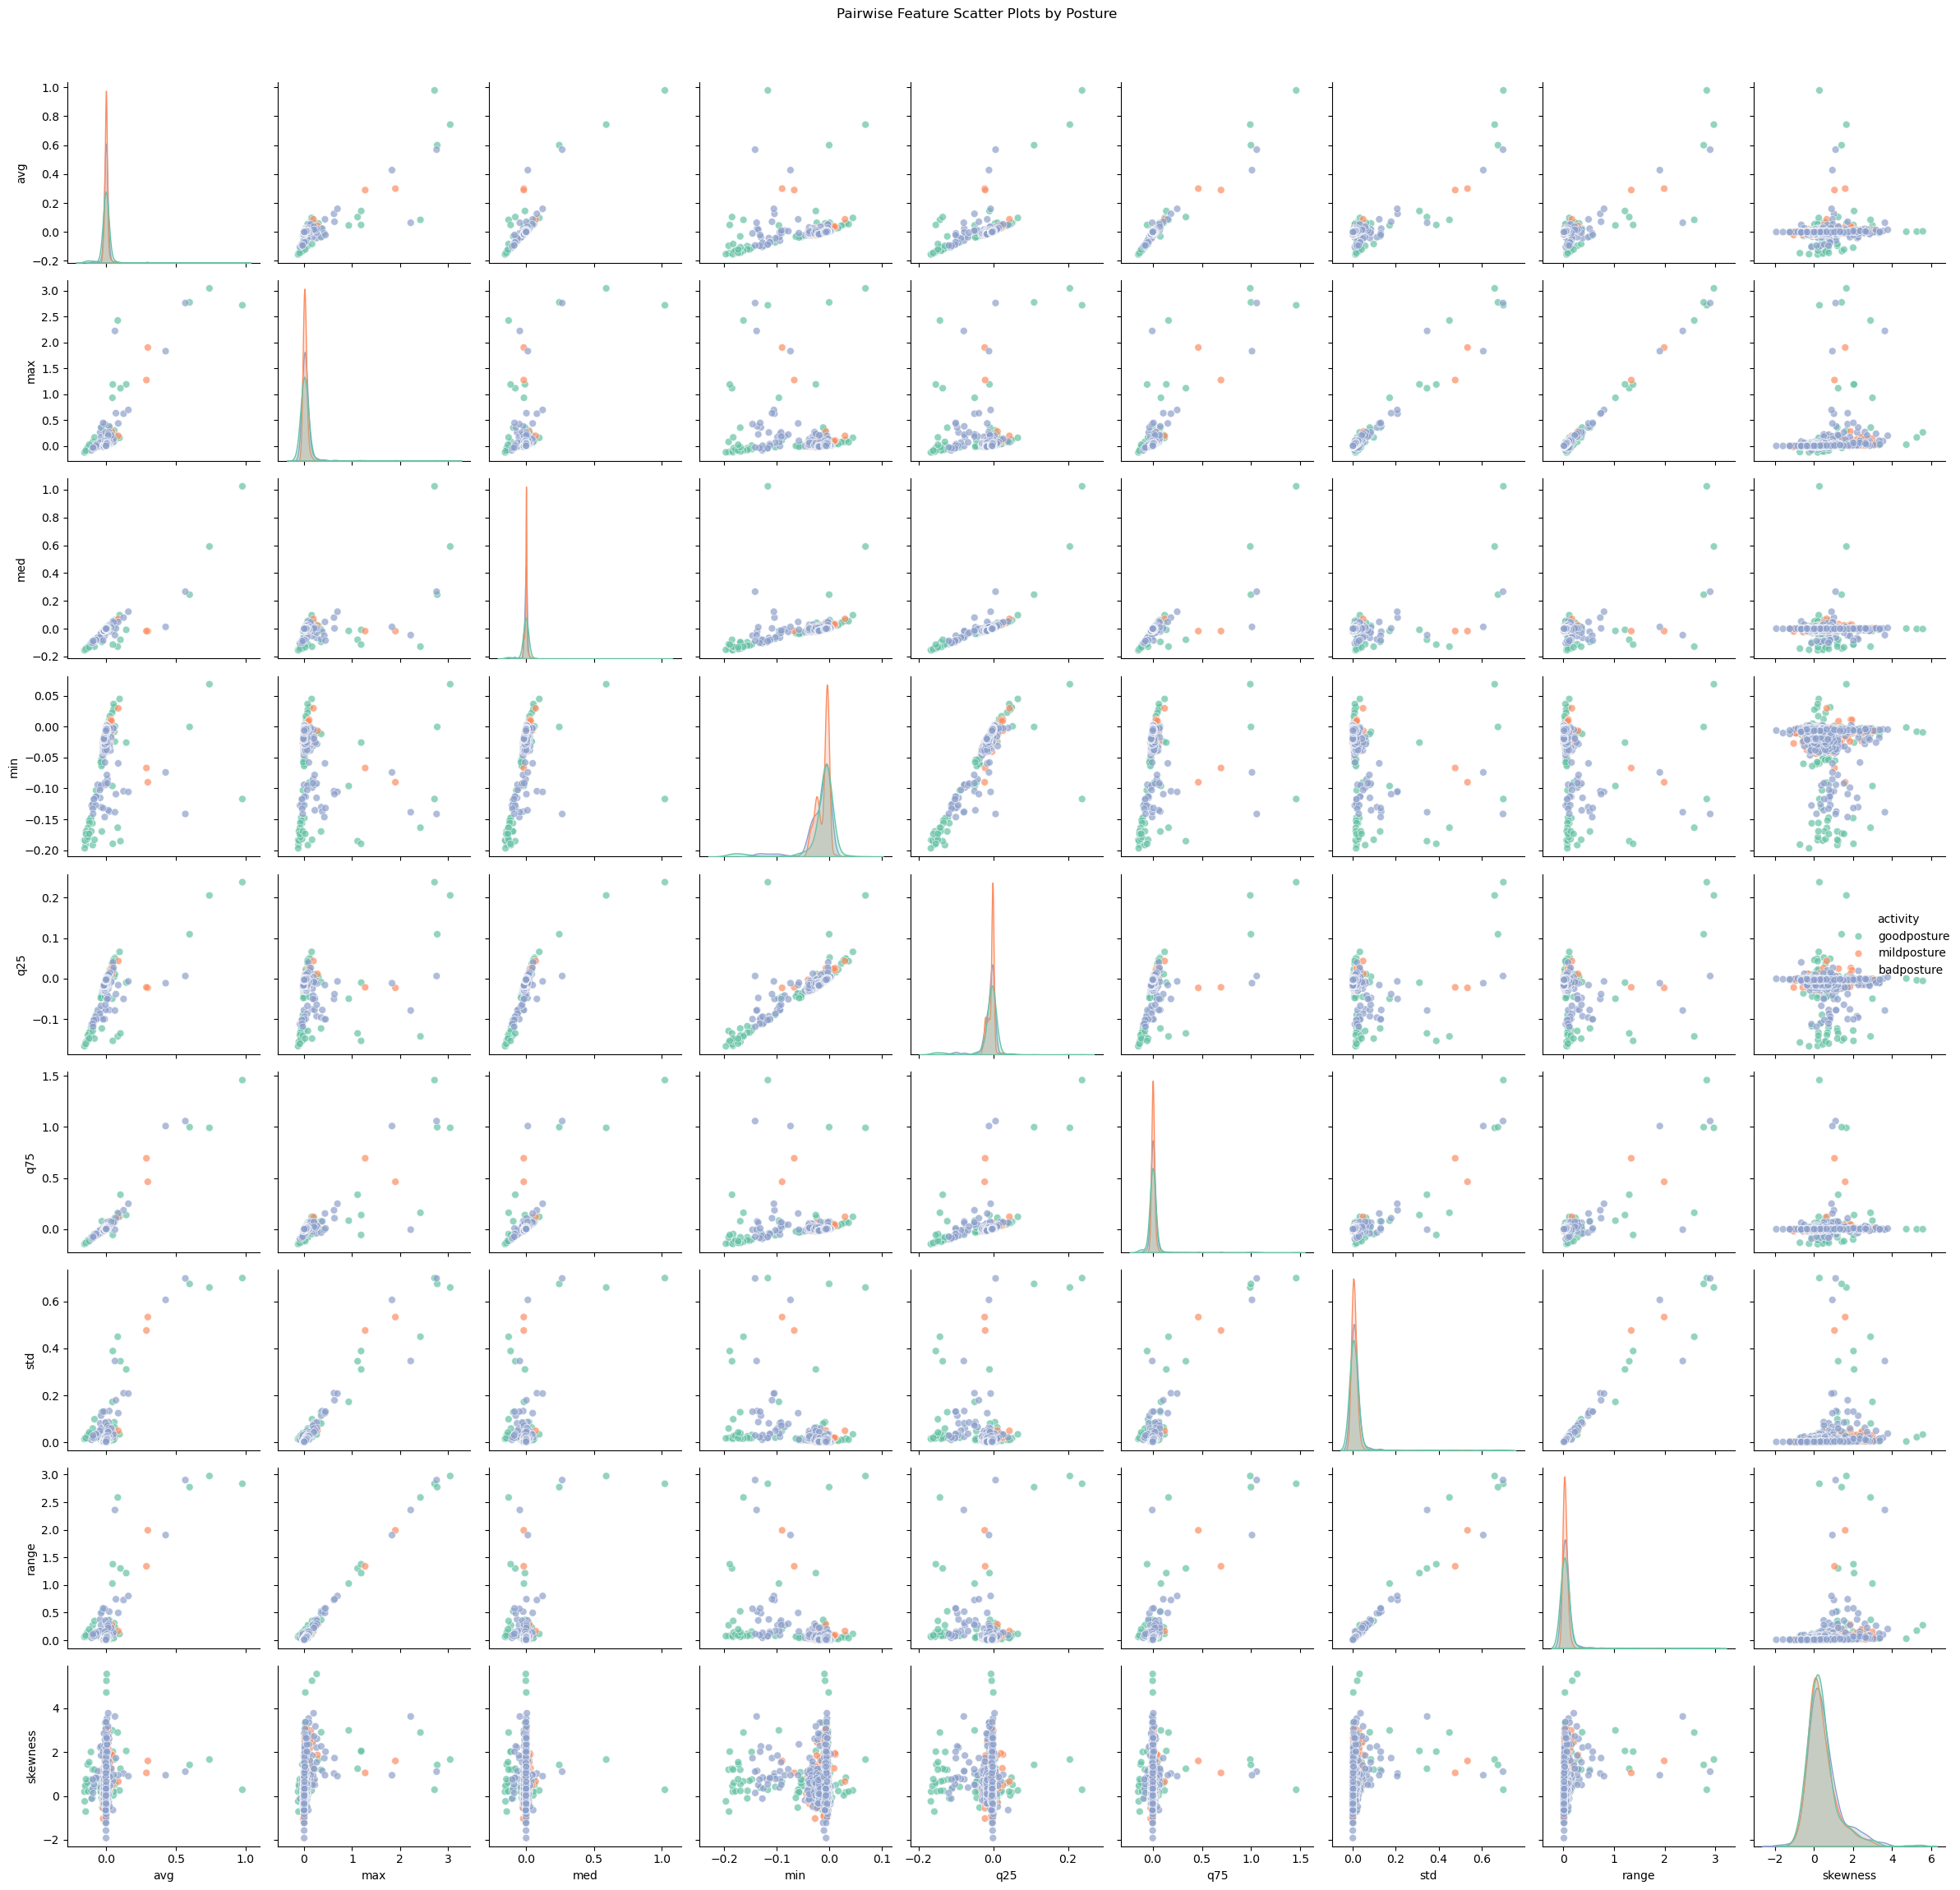

In [11]:
import seaborn as sns

def plot_all_feature_pairs(frames):
    feature_cols = ['avg', 'max', 'med', 'min', 'q25', 'q75', 'std', 'range', 'skewness']
    df = frames[feature_cols + ['activity']].copy()

    sns.pairplot(df, hue='activity', palette='Set2', plot_kws={'s': 40, 'alpha': 0.7})
    plt.suptitle("Pairwise Feature Scatter Plots by Posture", y=1.02)
    plt.tight_layout()
    plt.show()

plot_all_feature_pairs(frames)


### Feature Correlation Heatmap

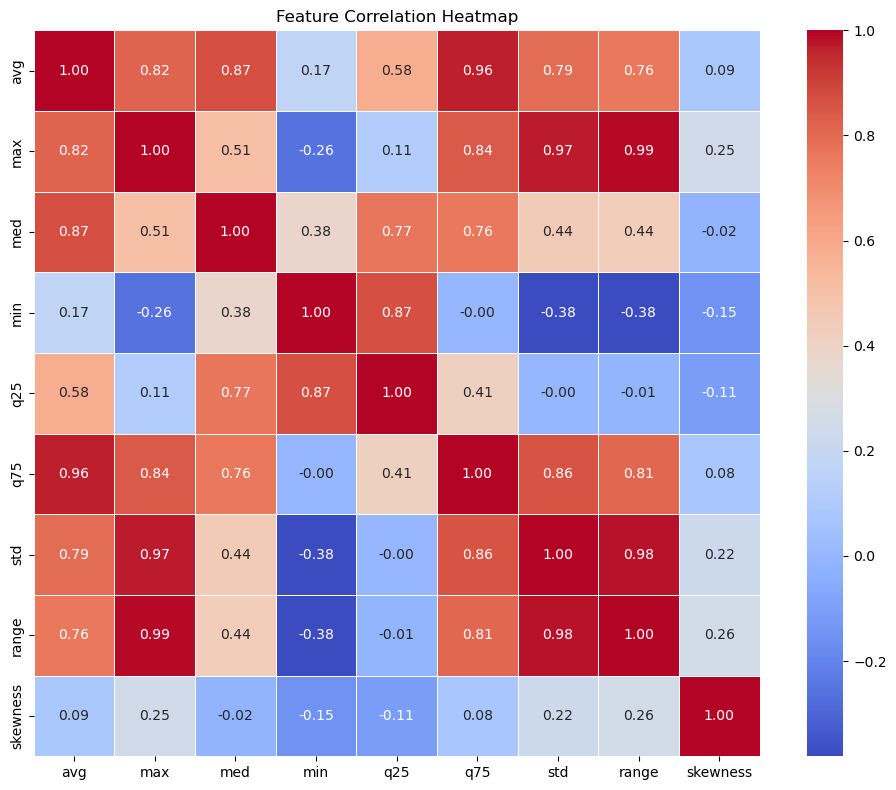

In [12]:
def plot_feature_correlation_heatmap(frames):
    feature_cols = ['avg', 'max', 'med', 'min', 'q25', 'q75', 'std', 'range', 'skewness']
    corr = frames[feature_cols].corr()

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', square=True, linewidths=0.5)
    plt.title("Feature Correlation Heatmap")
    plt.tight_layout()
    plt.show()

plot_feature_correlation_heatmap(frames)
